# 02 - STFT and spectrogram

A plain FFT tells us **which** frequencies are present, but not **when**. For
music, time matters (chords change), so we use the **short-time Fourier
transform (STFT)**: split the signal into short overlapping windows and apply an
FFT to each. In this notebook we:

1. explain and compare **window functions** (Hann, Hamming, Blackman),
2. demonstrate **spectral leakage**,
3. plot the **spectrogram** of a synthetic and a real signal,
4. explore the **time-frequency resolution** trade-off.

All implementations live in `src/stft.py`.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
from matplotlib import pyplot as plt

import common
import stft as ST

## 1. Window functions

The FFT implicitly assumes the signal is periodic. When we cut out a short
segment, its edges usually don't match up, and that jump introduces spurious
frequencies. **Window functions** taper the segment edges smoothly to zero and
reduce this effect.

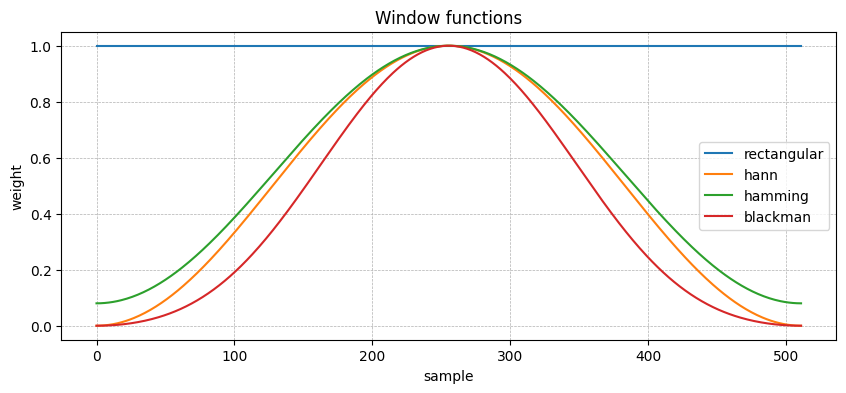

window functions OK


In [3]:
M = 512
plt.figure(figsize=(10, 4))
for name in ['rectangular', 'hann', 'hamming', 'blackman']:
    plt.plot(ST.make_window(name, M), label=name)
plt.title('Window functions')
plt.xlabel('sample'); plt.ylabel('weight')
plt.legend(); plt.grid(linestyle='--', linewidth=0.5)
plt.show()

assert np.allclose(ST.make_window('rectangular', M), 1.0)
hann = ST.make_window('hann', M)
assert hann[0] < 1e-9 and hann[-1] < 1e-9
print('window functions OK')

## 2. Spectral leakage

Take a pure sine whose frequency does **not** land exactly on an FFT bin.
Without a window (rectangular), energy leaks into neighbouring bins; with a Hann
window the peak is much cleaner.

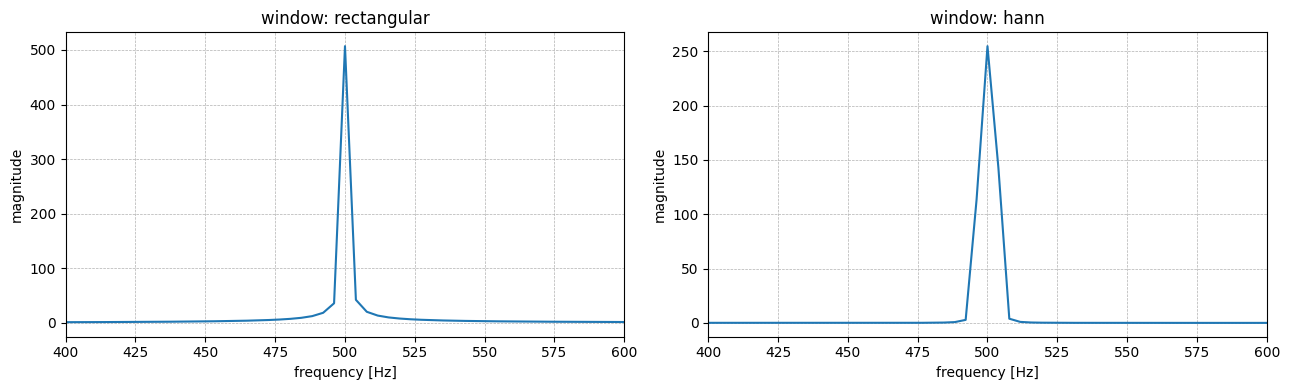

In [4]:
Fs = 4000
t = np.arange(0, 0.256, 1 / Fs)   
f0 = 500.3                       
sine = np.sin(2 * np.pi * f0 * t)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, name in zip(axes, ['rectangular', 'hann']):
    w = ST.make_window(name, len(sine))
    spectrum = np.abs(np.fft.rfft(sine * w))
    freq = np.fft.rfftfreq(len(sine), 1 / Fs)
    ax.plot(freq, spectrum)
    ax.set_xlim(400, 600)
    ax.set_title(f'window: {name}')
    ax.set_xlabel('frequency [Hz]'); ax.set_ylabel('magnitude')
    ax.grid(linestyle='--', linewidth=0.5)
plt.tight_layout(); plt.show()

## 3. Spectrogram of a rising scale

We build a signal that plays a sequence of tones (a rising scale) and plot its
spectrogram. It clearly shows **when** each note is played and how the frequency
rises. We reuse `note_to_freq` / `generate_tone` from `common.py`.

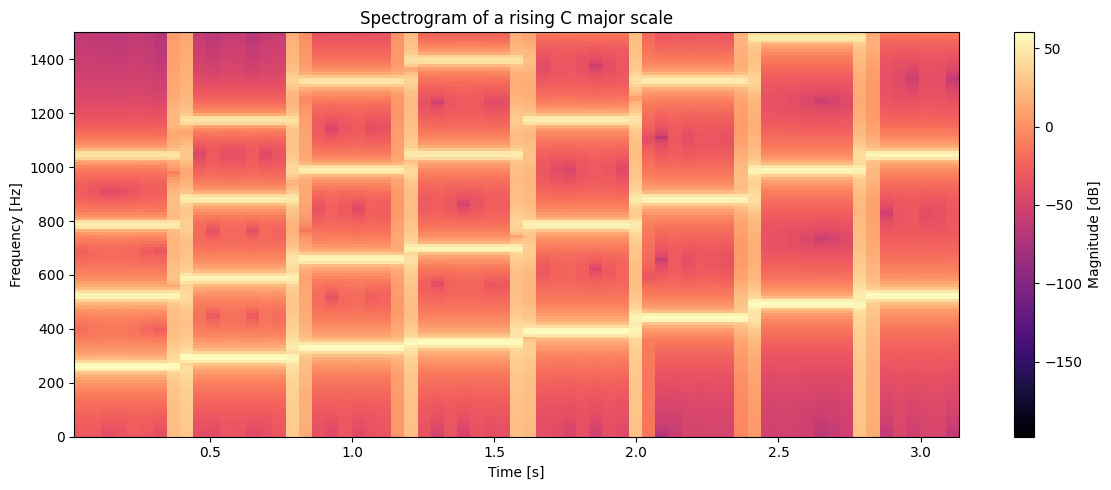

In [5]:
Fs = 44100
midi_notes = [60, 62, 64, 65, 67, 69, 71, 72]   
parts = [common.generate_tone(common.note_to_freq(m), 0.4, Fs, num_harmonics=4)
         for m in midi_notes]
scale = np.hstack(parts)

ST.plot_spectrogram(scale, Fs, window_size=4096, overlap=0.5,
                    ymax=1500, title='Spectrogram of a rising C major scale')
plt.show()

## 4. Time-frequency resolution trade-off

The window size sets the **resolution**. A short window gives good time
resolution (we see exactly when things happen) but poor frequency resolution,
and vice versa. This is the discrete form of the uncertainty principle for
signals.

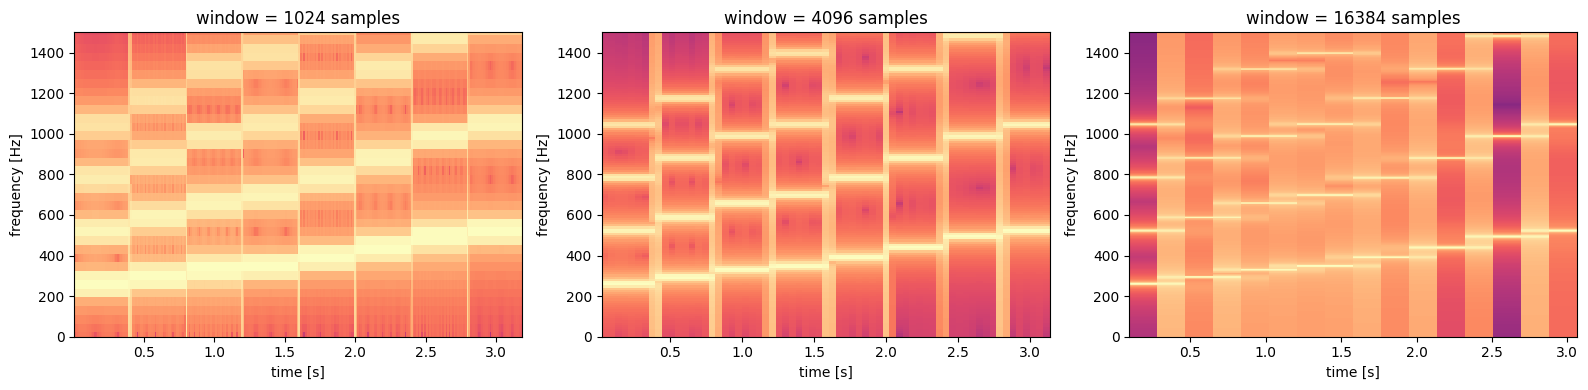

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, M in zip(axes, [1024, 4096, 16384]):
    f, tt, mag = ST.spectrogram(scale, Fs, window_size=M, overlap=0.5)
    ax.pcolormesh(tt, f, mag, shading='auto', cmap='magma')
    ax.set_ylim(0, 1500)
    ax.set_title(f'window = {M} samples')
    ax.set_xlabel('time [s]'); ax.set_ylabel('frequency [Hz]')
plt.tight_layout(); plt.show()

- **Small window (1024):** sharp time transitions, but smeared frequency lines.
- **Large window (16384):** thin, precise frequency lines, but blurred time transitions.

For chord detection later we pick a middle value (e.g. 4096) as a reasonable
compromise.

## 5. Spectrogram of a real recording

Finally, the same tool on a real piano recording, `data/piano.wav`.

/home/jovana/fft-music-analysis/notebooks/../src/common.py:64: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, data = wavfile.read(path)


piano.wav: Fs=44100, duration=5.05 s


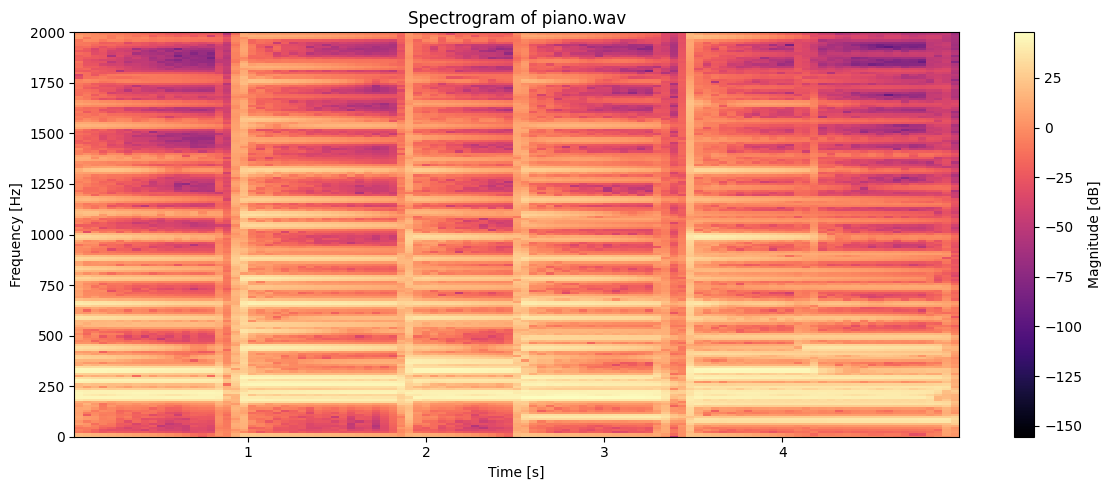

In [7]:
Fs_wav, piano = common.load_wav('../data/piano.wav')
print('piano.wav: Fs=%d, duration=%.2f s' % (Fs_wav, len(piano) / Fs_wav))

ST.plot_spectrogram(piano, Fs_wav, window_size=4096, overlap=0.5,
                    ymax=2000, title='Spectrogram of piano.wav')
plt.show()